In [1]:
# k nearest neighbors
from sklearn import neighbors
from sklearn import datasets
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

digits = datasets.load_digits()
X_digits = pd.DataFrame(digits.data)
y_digits = digits['target']

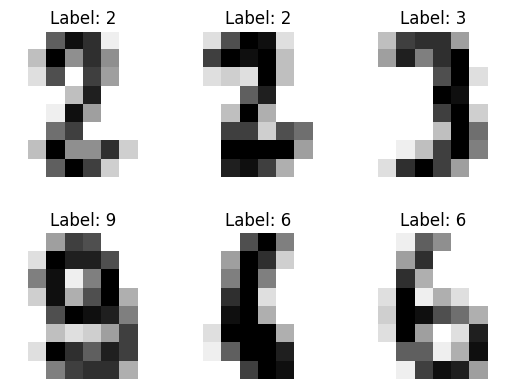

In [2]:
import matplotlib.pyplot as plt
from matplotlib import cm

j=0

for i in np.random.choice(np.arange(0, len(y_digits)), size=6):
    j=j+1    
    plt.subplot(2,3,j)
    plt.axis('off')    
    plt.imshow(digits.images[i],cmap = cm.binary, interpolation='None')
    plt.title('Label: %i' %y_digits[i])

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_digits, y_digits, test_size=0.2, random_state=126)

In [6]:
knn = neighbors.KNeighborsClassifier(n_neighbors=7, metric='minkowski')
knn.fit(X_train,y_train)
y_pred = knn.predict(X_test)
pd.crosstab(y_test, y_pred, rownames=['Classe réelle'], colnames=['Classe prédite'])

Classe prédite,0,1,2,3,4,5,6,7,8,9
Classe réelle,,,,,,,,,,
0,32,0,0,0,0,0,0,0,0,0
1,0,54,0,0,0,0,0,0,0,0
2,0,0,38,0,0,0,0,0,0,0
3,0,0,0,28,0,0,0,0,0,0
4,0,0,0,0,41,0,0,0,0,0
5,0,0,0,0,0,40,1,0,0,2
6,0,0,0,0,0,0,35,0,0,0
7,0,0,0,0,0,0,0,27,0,0
8,0,0,0,0,0,0,0,0,34,0


In [8]:
knn_m = neighbors.KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_m.fit(X_train, y_train)

score_minkowski = knn.score(X_test, y_test)
score_manhattan = knn_m.score(X_test, y_test)
print("Score Minkowski :",score_minkowski)
print("Score Manhattan :",score_manhattan)

Score Minkowski : 0.9805555555555555
Score Manhattan : 0.9861111111111112


In [9]:
score_minko = []
score_man = []
score_cheb = []

for k in range(1, 41):
    knn = neighbors.KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score_minko.append(knn.score(X_test, y_test))

for k in range(1, 41):
    knn = neighbors.KNeighborsClassifier(n_neighbors=k, metric='manhattan')
    knn.fit(X_train, y_train)
    score_man.append(knn.score(X_test, y_test))
    
for k in range(1, 41):
    knn = neighbors.KNeighborsClassifier(n_neighbors=k, metric='chebyshev')
    knn.fit(X_train, y_train)
    score_cheb.append(knn.score(X_test, y_test))

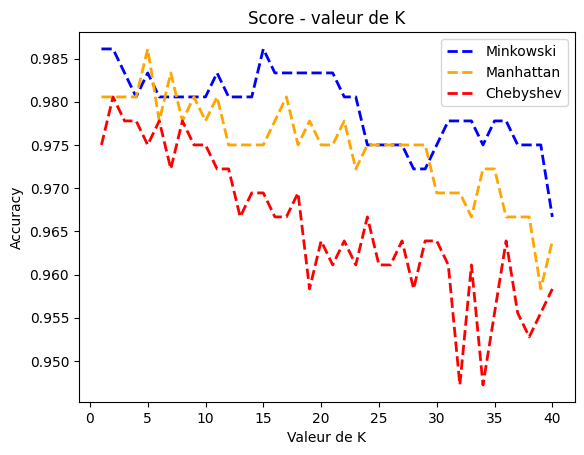

In [10]:
import matplotlib.pyplot as plt

plt.plot(range(1, 41), score_minko, color='blue', linestyle='dashed', lw=2, label='Minkowski')
plt.plot(range(1, 41), score_man, color='orange', linestyle='dashed', lw=2, label='Manhattan')
plt.plot(range(1, 41), score_cheb, color='red', linestyle='dashed', lw=2, label='Chebyshev')
plt.title('Score - valeur de K')  
plt.xlabel('Valeur de K')  
plt.ylabel('Accuracy') 
plt.legend();